# Pakistan Multi-Hazard Risk Analyzer — ML Pipeline

End-to-end training pipeline for flood, heatwave, and seismic risk
classification across 150 Pakistani districts.

**Data**: Synthetic (see `generate_data.py`), physically-derived risk
labels conditioned on real geography. **Not measured/observed data.**

**Pipeline**: EDA → RobustScaler + OneHot preprocessing (`sklearn.Pipeline`)
→ baseline model comparison (RandomForest / XGBoost / CatBoost) →
Optuna hyperparameter tuning of the winning family per target →
StratifiedKFold cross-validation → SHAP explainability → joblib
serialization for Streamlit deployment.

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from catboost import CatBoostClassifier
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-8s | %(message)s")
logger = logging.getLogger("ndma_hazard_pipeline")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 110

SEED = 42
DATA_PATH = Path("data/pakistan_districts.csv")
MODEL_DIR = Path("models")
IMAGE_DIR = Path("images")
MODEL_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)

np.random.seed(SEED)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
logger.info("Loaded %d rows, %d columns from %s", *df.shape, DATA_PATH)
df.head()

2026-09-10 09:16:15,474 | INFO     | Loaded 150 rows, 19 columns from data/pakistan_districts.csv


,district_name,province,latitude,longitude,elevation_m,avg_annual_rainfall_mm,river_proximity_km,population_density,avg_summer_temp_celsius,historical_flood_events,historical_earthquake_events,historical_disasters,soil_type,vegetation_index_ndvi,infrastructure_quality_score,flood_risk,heatwave_risk,seismic_risk,overall_risk_score
0,Lahore,Punjab,30.4940,73.7802,201.5,428.6,11.92,1215.0,38.8,2,0,2,alluvial,0.442,7.1,1,1,0,7.4
1,Faisalabad,Punjab,30.9731,73.9280,206.4,501.4,0.20,3.0,35.2,5,0,5,rocky,0.097,5.4,0,1,1,6.6
2,Rawalpindi,Punjab,29.6351,71.8723,343.1,685.1,21.75,617.1,37.0,2,0,2,sandy,0.577,6.7,1,0,0,2.9
3,Multan,Punjab,32.4070,71.6678,280.2,489.5,3.75,761.8,32.1,7,0,7,sandy,0.151,5.4,1,0,0,3.1
4,Gujranwala,Punjab,32.2445,74.0444,222.8,376.0,14.41,803.6,37.9,9,1,10,alluvial,0.506,7.4,1,0,1,6.7


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   district_name                 150 non-null    str    
 1   province                      150 non-null    str    
 2   latitude                      150 non-null    float64
 3   longitude                     150 non-null    float64
 4   elevation_m                   150 non-null    float64
 5   avg_annual_rainfall_mm        150 non-null    float64
 6   river_proximity_km            150 non-null    float64
 7   population_density            150 non-null    float64
 8   avg_summer_temp_celsius       150 non-null    float64
 9   historical_flood_events       150 non-null    int64  
 10  historical_earthquake_events  150 non-null    int64  
 11  historical_disasters          150 non-null    int64  
 12  soil_type                     150 non-null    str    
 13  vegetation_index

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
district_name,150,150,Lahore,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,150,7,Punjab,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,150.0,NaN,NaN,NaN,30.519709,3.205503,23.6,28.1772,30.8689,32.793975,36.8685
longitude,150.0,NaN,NaN,NaN,70.258288,3.223372,61.1911,68.296925,71.3406,72.754825,75.5668
elevation_m,150.0,NaN,NaN,NaN,538.700509,1025.462861,0.0,77.225,218.0,665.075,7672.811233
avg_annual_rainfall_mm,150.0,NaN,NaN,NaN,426.026526,297.083023,30.0,202.975,349.85,626.6,1484.8
river_proximity_km,150.0,NaN,NaN,NaN,27.287271,24.916557,0.2,9.35,21.38,34.345,120.88
population_density,150.0,NaN,NaN,NaN,534.978,492.340255,3.0,106.625,459.05,808.525,3044.5
avg_summer_temp_celsius,150.0,NaN,NaN,NaN,33.693742,5.822417,15.1,30.3,34.8,37.475,51.214658
historical_flood_events,150.0,NaN,NaN,NaN,4.353333,2.627007,0.0,2.0,4.0,6.0,12.0


## 2. Exploratory Data Analysis

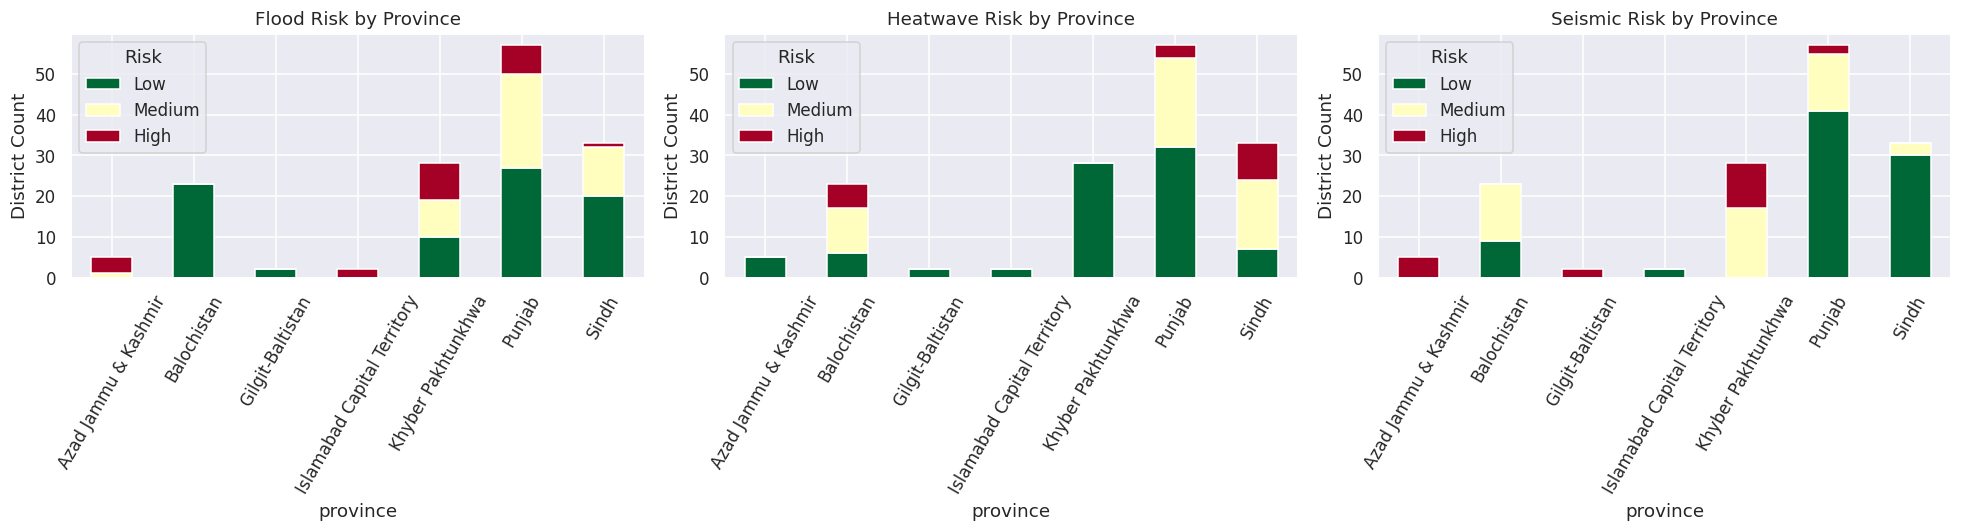

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, target in zip(axes, ["flood_risk", "heatwave_risk", "seismic_risk"]):
    pd.crosstab(df["province"], df[target]).plot(
        kind="bar", stacked=True, ax=ax, colormap="RdYlGn_r"
    )
    ax.set_title(f"{target.replace('_', ' ').title()} by Province")
    ax.set_ylabel("District Count")
    ax.legend(["Low", "Medium", "High"], title="Risk")
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "risk_by_province.png", bbox_inches="tight")
plt.show()

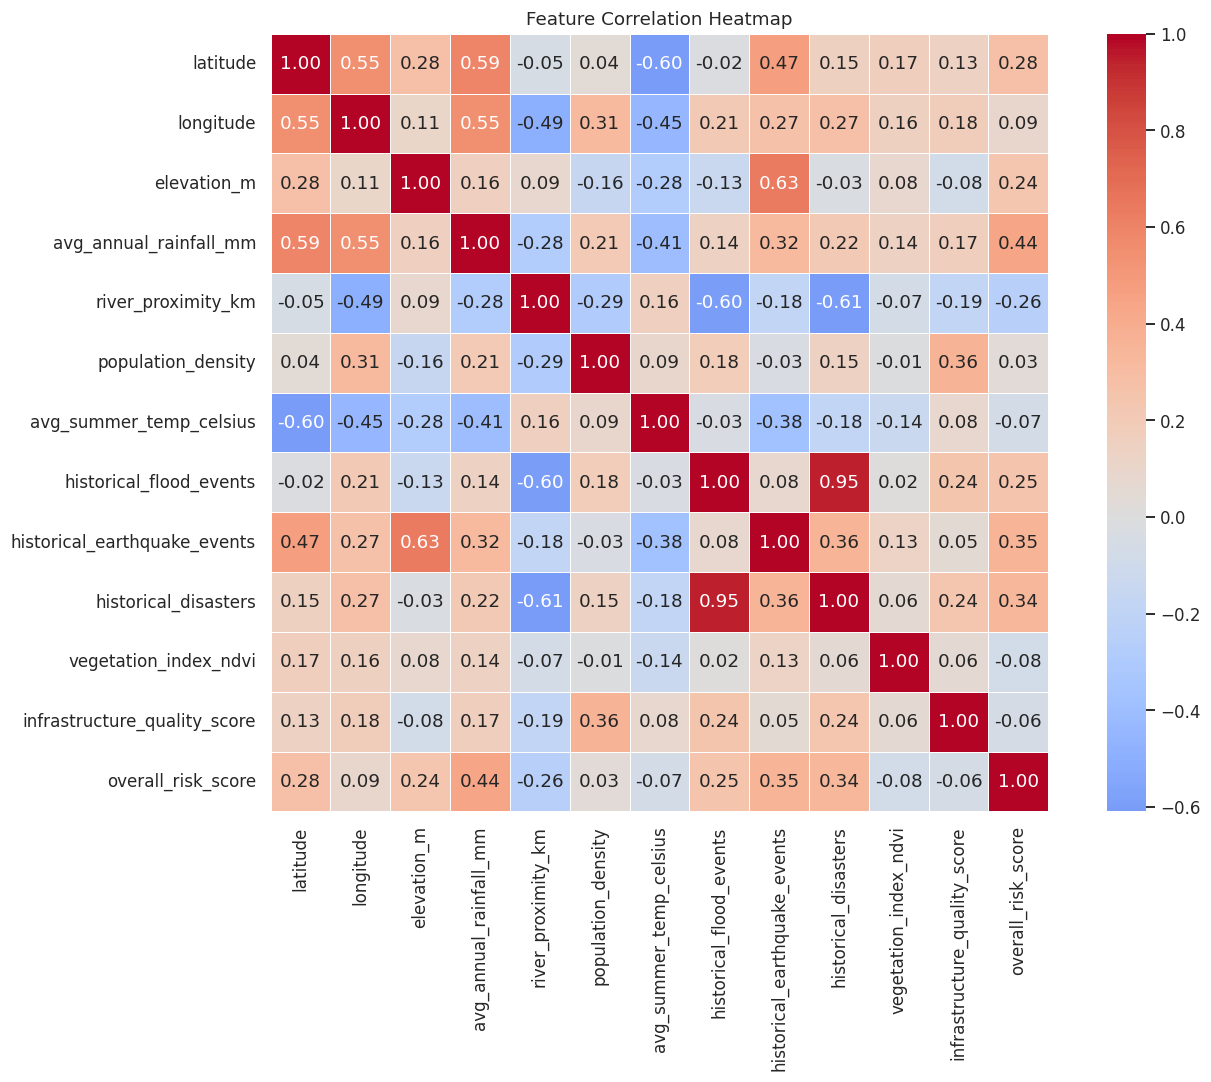

In [6]:
numeric_cols = [
    "latitude", "longitude", "elevation_m", "avg_annual_rainfall_mm",
    "river_proximity_km", "population_density", "avg_summer_temp_celsius",
    "historical_flood_events", "historical_earthquake_events",
    "historical_disasters", "vegetation_index_ndvi",
    "infrastructure_quality_score", "overall_risk_score",
]
plt.figure(figsize=(13, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

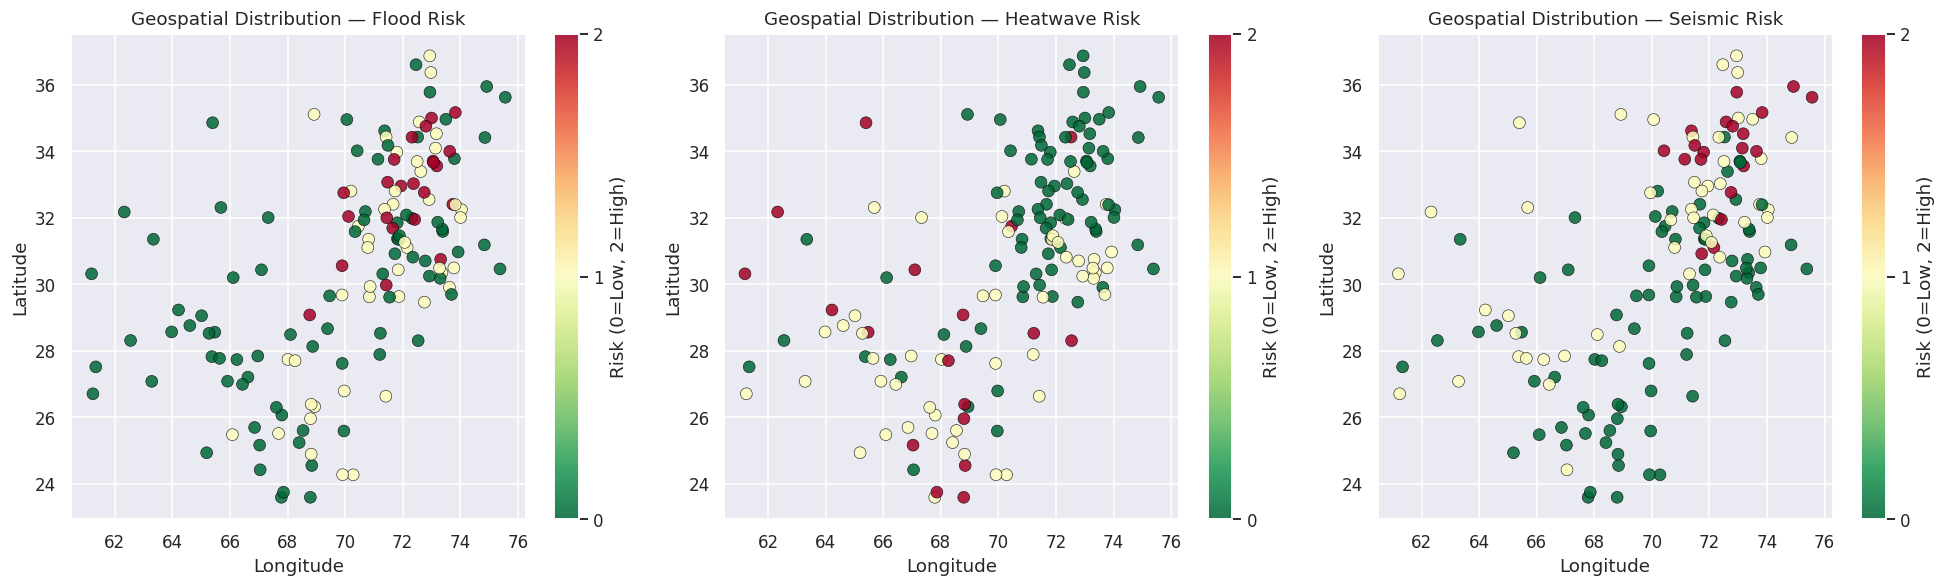

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, target in zip(axes, ["flood_risk", "heatwave_risk", "seismic_risk"]):
    scatter = ax.scatter(
        df["longitude"], df["latitude"], c=df[target],
        cmap="RdYlGn_r", s=60, edgecolor="black", linewidth=0.4, alpha=0.85,
    )
    ax.set_title(f"Geospatial Distribution — {target.replace('_', ' ').title()}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(scatter, ax=ax, label="Risk (0=Low, 2=High)", ticks=[0, 1, 2])
plt.tight_layout()
plt.savefig(IMAGE_DIR / "geospatial_risk_scatter.png", bbox_inches="tight")
plt.show()

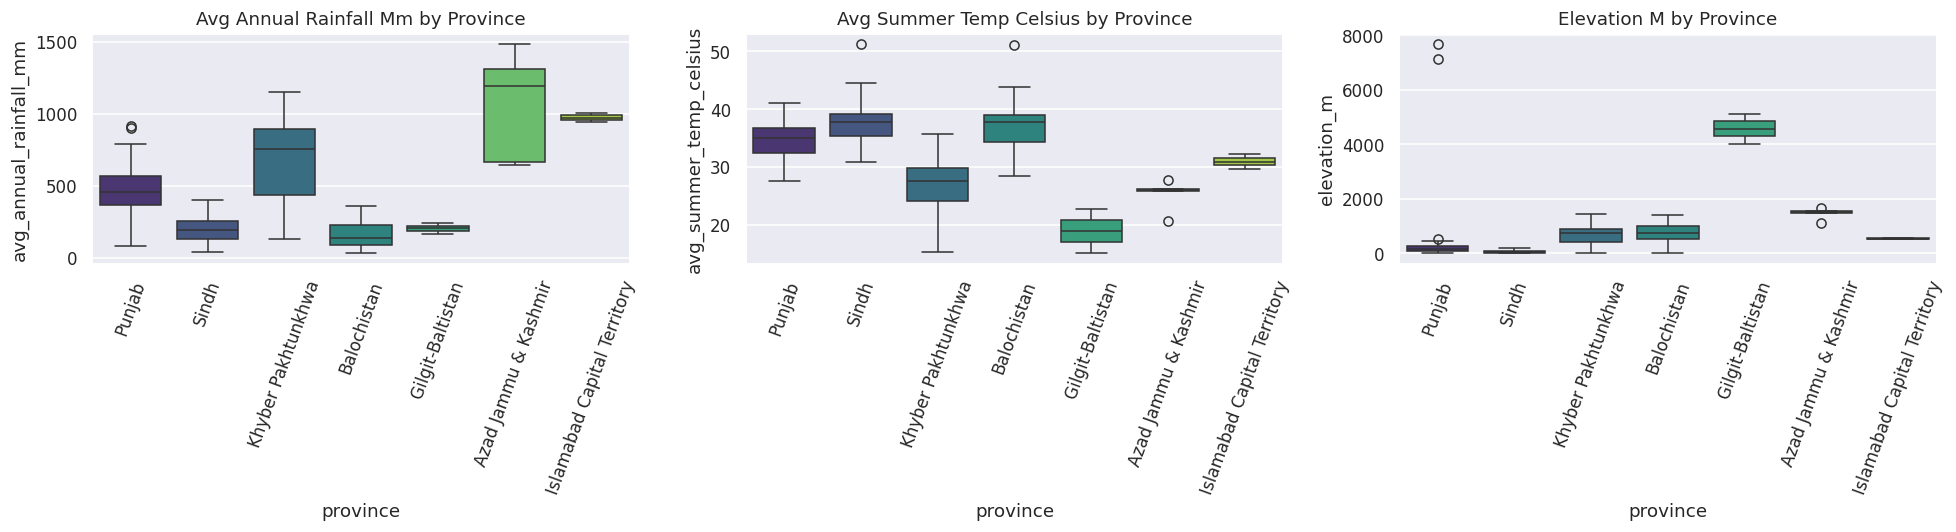

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (target, feature) in zip(
    axes,
    [
        ("flood_risk", "avg_annual_rainfall_mm"),
        ("heatwave_risk", "avg_summer_temp_celsius"),
        ("seismic_risk", "elevation_m"),
    ],
):
    sns.boxplot(data=df, x="province", y=feature, ax=ax, palette="viridis")
    ax.set_title(f"{feature.replace('_', ' ').title()} by Province")
    ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_boxplots_by_province.png", bbox_inches="tight")
plt.show()

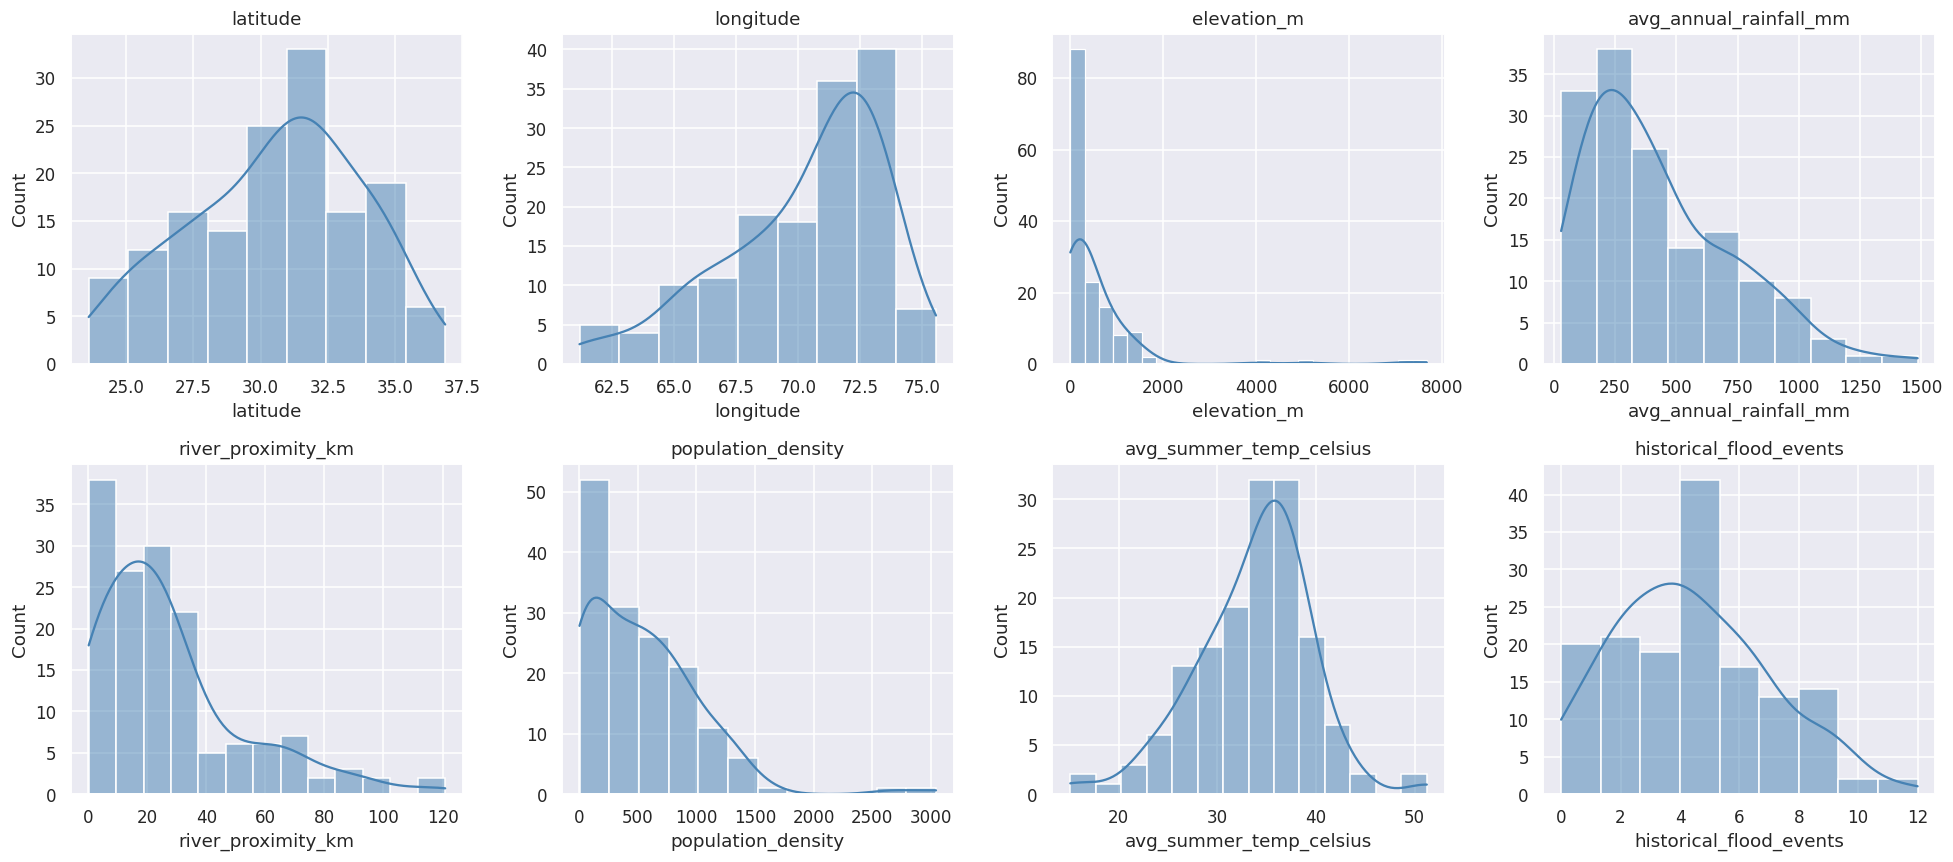

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols[:8]):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_distributions.png", bbox_inches="tight")
plt.show()

## 3. Preprocessing Pipeline

`RobustScaler` is used instead of `StandardScaler` because the dataset
deliberately contains injected extreme outliers (climate anomalies).
RobustScaler centers/scales using median and IQR, so a handful of
extreme rainfall/elevation rows cannot distort the scaling applied to
every other district.

In [10]:
NUMERIC_FEATURES = [
    "latitude", "longitude", "elevation_m", "avg_annual_rainfall_mm",
    "river_proximity_km", "population_density", "avg_summer_temp_celsius",
    "historical_flood_events", "historical_earthquake_events",
    "historical_disasters", "vegetation_index_ndvi",
    "infrastructure_quality_score",
]
CATEGORICAL_FEATURES = ["province", "soil_type"]
TARGETS = ["flood_risk", "heatwave_risk", "seismic_risk"]

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)
logger.info("Preprocessor: RobustScaler(%d numeric) + OneHot(%d categorical)",
            len(NUMERIC_FEATURES), len(CATEGORICAL_FEATURES))

2026-09-10 09:16:19,950 | INFO     | Preprocessor: RobustScaler(12 numeric) + OneHot(2 categorical)


## 4. Baseline Model Comparison (per target)

n=150 is small for 5-fold CV once split 3 ways by class, so folds are
stratified and the fold count is automatically reduced for any target
whose minority class has fewer than 5 members (prevents an empty-fold
crash while staying maximally granular otherwise).

In [11]:
N_SPLITS = 5


def get_cv(y: pd.Series) -> StratifiedKFold:
    n_splits = min(N_SPLITS, y.value_counts().min())
    if n_splits < N_SPLITS:
        logger.warning(
            "Smallest class has %d samples; using %d folds instead of %d.",
            y.value_counts().min(), n_splits, N_SPLITS,
        )
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)


def get_baseline_models() -> dict:
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=SEED
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300, eval_metric="mlogloss", random_state=SEED, verbosity=0
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300, auto_class_weights="Balanced", random_state=SEED, verbose=False
        ),
    }


baseline_results: dict[str, dict] = {}

for target in TARGETS:
    y = df[target]
    cv = get_cv(y)
    logger.info("=== %s | class distribution: %s ===", target, y.value_counts().to_dict())

    scores = {}
    for name, model in get_baseline_models().items():
        pipe = Pipeline([("prep", preprocessor), ("clf", model)])
        preds = cross_val_predict(pipe, X, y, cv=cv, method="predict")
        macro_f1 = f1_score(y, preds, average="macro")
        scores[name] = macro_f1
        logger.info("  %-13s macro-F1 = %.4f", name, macro_f1)

    best_family = max(scores, key=scores.get)
    baseline_results[target] = {"scores": scores, "best_family": best_family}
    logger.info("  -> Winning family for %s: %s\n", target, best_family)

pd.DataFrame({t: r["scores"] for t, r in baseline_results.items()}).round(4)

2026-09-10 09:16:19,959 | INFO     | === flood_risk | class distribution: {0: 82, 1: 45, 2: 23} ===


2026-09-10 09:16:21,316 | INFO     |   RandomForest  macro-F1 = 0.6545


2026-09-10 09:16:21,659 | INFO     |   XGBoost       macro-F1 = 0.6283


2026-09-10 09:16:23,909 | INFO     |   CatBoost      macro-F1 = 0.7017


2026-09-10 09:16:23,911 | INFO     |   -> Winning family for flood_risk: CatBoost



...

2026-09-10 09:16:29,233 | INFO     |   RandomForest  macro-F1 = 0.6753


2026-09-10 09:16:29,594 | INFO     |   XGBoost       macro-F1 = 0.6925


2026-09-10 09:16:31,827 | INFO     |   CatBoost      macro-F1 = 0.7611


2026-09-10 09:16:31,828 | INFO     |   -> Winning family for seismic_risk: CatBoost



,flood_risk,heatwave_risk,seismic_risk
RandomForest,0.6545,0.4998,0.6753
XGBoost,0.6283,0.5241,0.6925
CatBoost,0.7017,0.5717,0.7611


## 5. Optuna Hyperparameter Tuning

Only the winning family per target is tuned (not all 3 families x 3
targets = 9 full studies) — the baseline pass already identifies the
best architecture; Optuna's budget goes toward tuning that one
architecture well rather than spreading thin across all of them.

In [12]:
def build_model(family: str, trial: optuna.Trial):
    """Instantiate a model of the given family with Optuna-suggested
    hyperparameters for this trial.
    """
    if family == "CatBoost":
        return CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 100, 600),
            depth=trial.suggest_int("depth", 3, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            auto_class_weights="Balanced",
            random_state=SEED,
            verbose=False,
        )
    if family == "XGBoost":
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 600),
            max_depth=trial.suggest_int("max_depth", 3, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            eval_metric="mlogloss", random_state=SEED, verbosity=0,
        )
    # RandomForest
    return RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        class_weight="balanced", random_state=SEED,
    )


N_OPTUNA_TRIALS = 30
tuned_results: dict[str, dict] = {}

for target in TARGETS:
    y = df[target]
    cv = get_cv(y)
    family = baseline_results[target]["best_family"]
    logger.info("Tuning %s (%s) with Optuna — %d trials...", target, family, N_OPTUNA_TRIALS)

    def objective(trial: optuna.Trial, target=target, family=family, y=y, cv=cv) -> float:
        model = build_model(family, trial)
        pipe = Pipeline([("prep", preprocessor), ("clf", model)])
        preds = cross_val_predict(pipe, X, y, cv=cv, method="predict")
        return f1_score(y, preds, average="macro")

    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

    tuned_results[target] = {
        "family": family,
        "best_params": study.best_params,
        "best_f1": study.best_value,
        "study": study,
    }
    logger.info(
        "  %s tuned macro-F1 = %.4f (baseline was %.4f) | params=%s",
        target, study.best_value, baseline_results[target]["scores"][family], study.best_params,
    )

2026-09-10 09:16:31,843 | INFO     | Tuning flood_risk (CatBoost) with Optuna — 30 trials...


2026-09-10 09:17:41,938 | INFO     |   flood_risk tuned macro-F1 = 0.7163 (baseline was 0.7017) | params={'iterations': 410, 'depth': 5, 'learning_rate': 0.027710915259677758, 'l2_leaf_reg': 1.0321540526046158}


2026-09-10 09:17:41,941 | INFO     | Tuning heatwave_risk (CatBoost) with Optuna — 30 trials...


2026-09-10 09:19:36,185 | INFO     |   heatwave_risk tuned macro-F1 = 0.6655 (baseline was 0.5717) | params={'iterations': 160, 'depth': 8, 'learning_rate': 0.20676202541895256, 'l2_leaf_reg': 5.62085398757569}


2026-09-10 09:19:36,187 | INFO     | Tuning seismic_risk (CatBoost) with Optuna — 30 trials...


2026-09-10 09:20:29,058 | INFO     |   seismic_risk tuned macro-F1 = 0.7908 (baseline was 0.7611) | params={'iterations': 555, 'depth': 4, 'learning_rate': 0.012804888821362105, 'l2_leaf_reg': 6.930958239971343}


In [13]:
improvement_df = pd.DataFrame(
    {
        "target": TARGETS,
        "family": [tuned_results[t]["family"] for t in TARGETS],
        "baseline_f1": [baseline_results[t]["scores"][tuned_results[t]["family"]] for t in TARGETS],
        "tuned_f1": [tuned_results[t]["best_f1"] for t in TARGETS],
    }
)
improvement_df["improvement"] = improvement_df["tuned_f1"] - improvement_df["baseline_f1"]
improvement_df

,target,family,baseline_f1,tuned_f1,improvement
0,flood_risk,CatBoost,0.701733,0.716270,0.014537
1,heatwave_risk,CatBoost,0.571748,0.665458,0.093710
2,seismic_risk,CatBoost,0.761139,0.790765,0.029626


## 6. Final Model Training + StratifiedKFold Validation

In [14]:
final_pipelines: dict[str, Pipeline] = {}
cv_predictions: dict[str, np.ndarray] = {}

for target in TARGETS:
    y = df[target]
    cv = get_cv(y)
    family = tuned_results[target]["family"]
    best_params = tuned_results[target]["best_params"]

    final_model = build_model(family, optuna.trial.FixedTrial(best_params))
    final_pipe = Pipeline([("prep", preprocessor), ("clf", final_model)])

    # Out-of-fold predictions for honest evaluation (never scored on
    # training folds), then a final refit on 100% of data for deployment.
    oof_preds = cross_val_predict(final_pipe, X, y, cv=cv, method="predict")
    cv_predictions[target] = oof_preds

    final_pipe.fit(X, y)
    final_pipelines[target] = final_pipe

    logger.info("=== %s (%s) — Out-of-fold Classification Report ===", target, family)
    print(
        classification_report(
            y, oof_preds, target_names=["Low", "Medium", "High"], zero_division=0
        )
    )

2026-09-10 09:20:31,241 | INFO     | === flood_risk (CatBoost) — Out-of-fold Classification Report ===


              precision    recall  f1-score   support

         Low       0.86      0.84      0.85        82
      Medium       0.63      0.58      0.60        45
        High       0.62      0.78      0.69        23

    accuracy                           0.75       150
   macro avg       0.71      0.73      0.72       150
weighted avg       0.76      0.75      0.75       150



2026-09-10 09:20:35,589 | INFO     | === heatwave_risk (CatBoost) — Out-of-fold Classification Report ===


              precision    recall  f1-score   support

         Low       0.87      0.80      0.84        82
      Medium       0.61      0.66      0.63        50
        High       0.50      0.56      0.53        18

    accuracy                           0.73       150
   macro avg       0.66      0.67      0.67       150
weighted avg       0.74      0.73      0.73       150



2026-09-10 09:20:37,317 | INFO     | === seismic_risk (CatBoost) — Out-of-fold Classification Report ===


              precision    recall  f1-score   support

         Low       0.84      0.85      0.85        82
      Medium       0.69      0.65      0.67        48
        High       0.82      0.90      0.86        20

    accuracy                           0.79       150
   macro avg       0.78      0.80      0.79       150
weighted avg       0.79      0.79      0.79       150



## 7. Confusion Matrices

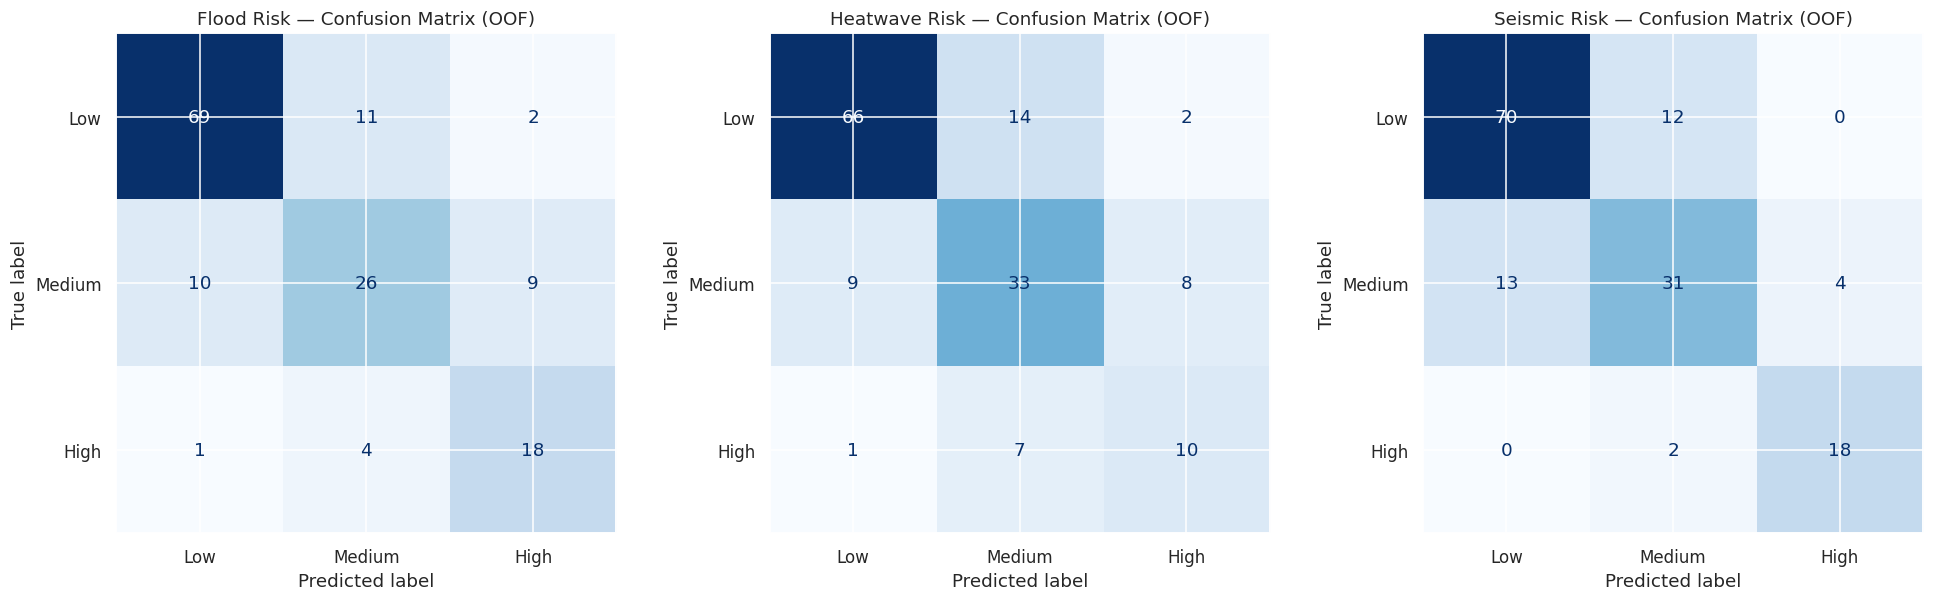

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, target in zip(axes, TARGETS):
    cm = confusion_matrix(df[target], cv_predictions[target])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{target.replace('_', ' ').title()} — Confusion Matrix (OOF)")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

## 8. SHAP Explainability

`shap.TreeExplainer` on the final tuned classifier (post-preprocessing
feature space). For multiclass tree models, `shap_values` returns an
array of shape `(n_samples, n_features, n_classes)` in this SHAP
version — indexed as `shap_values[:, :, class_idx]` per class, not as
a list of per-class arrays (a common versioning pitfall).

In [16]:
def get_shap_values_for_class(shap_values: np.ndarray | list, class_idx: int) -> np.ndarray:
    """Normalize SHAP's multiclass output across library versions.

    Handles both the modern ndarray layout (n_samples, n_features, n_classes)
    and the older list-of-arrays layout ([n_classes] x (n_samples, n_features)).
    """
    if isinstance(shap_values, list):
        return shap_values[class_idx]
    return shap_values[:, :, class_idx]


shap_summary_data: dict[str, tuple] = {}

for target in TARGETS:
    pipe = final_pipelines[target]
    X_transformed = pipe.named_steps["prep"].transform(X)
    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()
    feature_names = pipe.named_steps["prep"].get_feature_names_out()

    explainer = shap.TreeExplainer(pipe.named_steps["clf"])
    shap_values = explainer.shap_values(X_transformed)
    shap_summary_data[target] = (shap_values, X_transformed, feature_names)
    logger.info("SHAP values computed for %s.", target)

2026-09-10 09:20:38,222 | INFO     | SHAP values computed for flood_risk.


2026-09-10 09:20:39,326 | INFO     | SHAP values computed for heatwave_risk.


2026-09-10 09:20:39,451 | INFO     | SHAP values computed for seismic_risk.


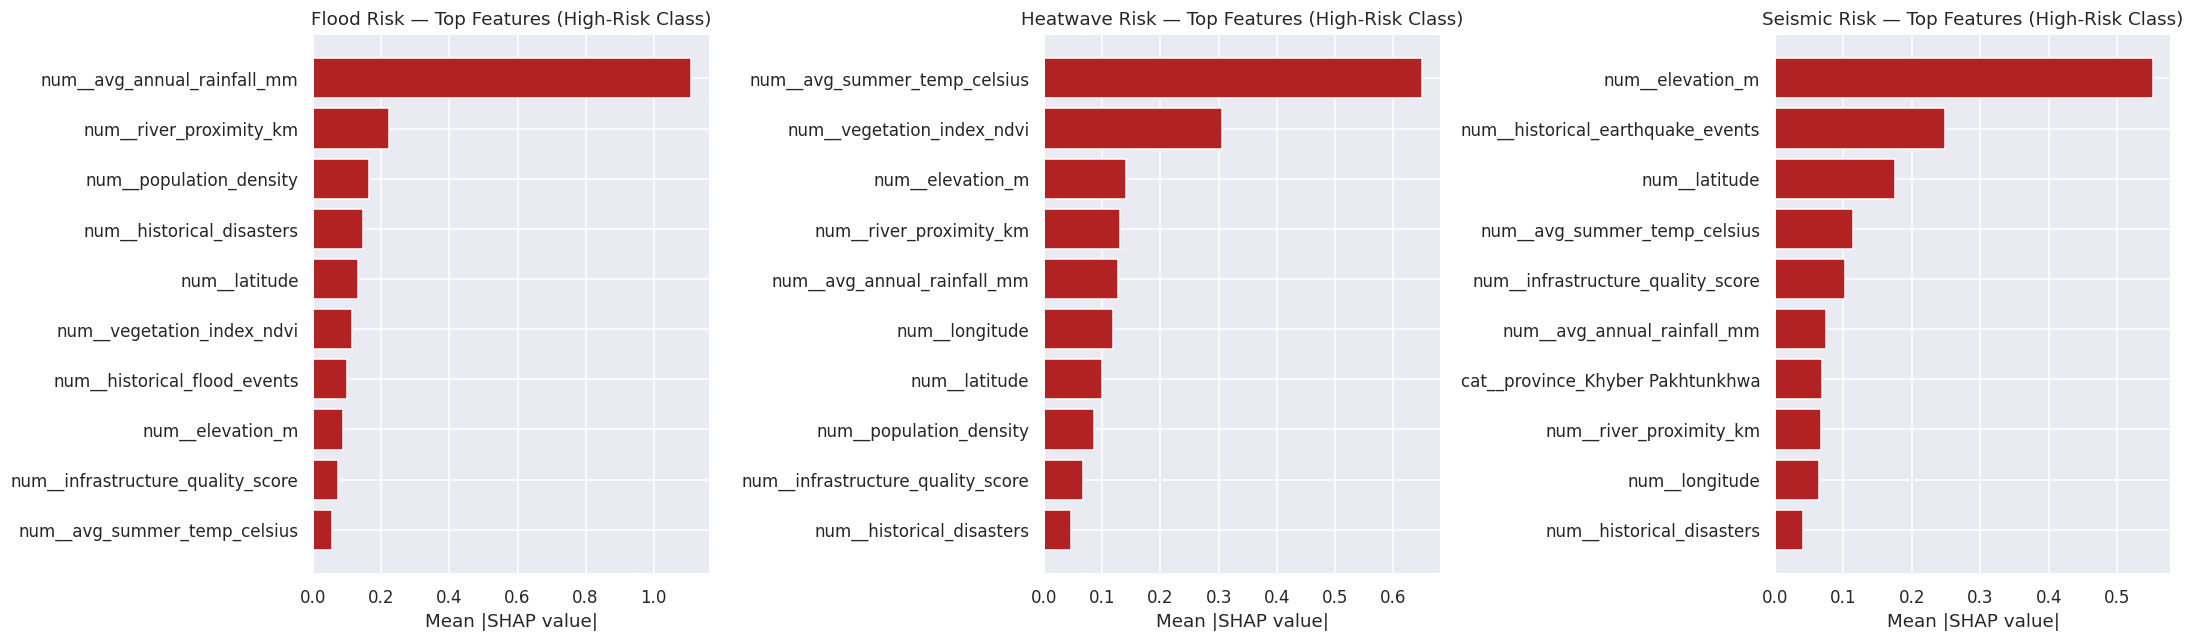

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, target in zip(axes, TARGETS):
    shap_values, X_transformed, feature_names = shap_summary_data[target]
    high_risk_shap = get_shap_values_for_class(shap_values, class_idx=2)  # "High" class

    mean_abs_shap = np.abs(high_risk_shap).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[-10:]

    ax.barh(np.array(feature_names)[top_idx], mean_abs_shap[top_idx], color="firebrick")
    ax.set_title(f"{target.replace('_', ' ').title()} — Top Features (High-Risk Class)")
    ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "shap_feature_importance.png", bbox_inches="tight")
plt.show()

## 9. Serialize Best Pipelines for Deployment

Saves a single joblib bundle containing all three tuned pipelines plus
metadata, so the Streamlit app can load one file and route predictions
by hazard type.

In [18]:
MODEL_BUNDLE_PATH = MODEL_DIR / "best_hazard_pipeline.pkl"

deployment_bundle = {
    "pipelines": final_pipelines,
    "targets": TARGETS,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "class_labels": ["Low", "Medium", "High"],
    "model_families": {t: tuned_results[t]["family"] for t in TARGETS},
    "cv_macro_f1": {t: tuned_results[t]["best_f1"] for t in TARGETS},
    "seed": SEED,
}

joblib.dump(deployment_bundle, MODEL_BUNDLE_PATH)
logger.info("Saved deployment bundle -> %s", MODEL_BUNDLE_PATH)

2026-09-10 09:20:40,096 | INFO     | Saved deployment bundle -> models/best_hazard_pipeline.pkl


In [19]:
# Reload sanity check.
# NOTE: CatBoostClassifier.predict() returns shape (n_samples, 1), while
# RandomForest/XGBoost return flat shape (n_samples,). np.asarray(...).ravel()
# normalizes both so downstream indexing never breaks depending on which
# family won the per-target Optuna search — a real cross-family gotcha
# caught by executing this notebook end-to-end before shipping it.
reloaded = joblib.load(MODEL_BUNDLE_PATH)
sample = X.iloc[[0]]
for target in TARGETS:
    raw_pred = reloaded["pipelines"][target].predict(sample)
    pred = int(np.asarray(raw_pred).ravel()[0])
    proba = reloaded["pipelines"][target].predict_proba(sample)[0]
    logger.info(
        "%s -> predicted=%s (actual=%s) | probs=%s",
        target, ["Low", "Medium", "High"][pred], ["Low", "Medium", "High"][df[target].iloc[0]],
        np.round(proba, 3),
    )

logger.info("Pipeline complete. Bundle ready for Streamlit deployment.")

2026-09-10 09:20:40,114 | INFO     | flood_risk -> predicted=Medium (actual=Medium) | probs=[0.108 0.839 0.052]


2026-09-10 09:20:40,122 | INFO     | heatwave_risk -> predicted=Medium (actual=Medium) | probs=[0.052 0.917 0.03 ]


2026-09-10 09:20:40,128 | INFO     | seismic_risk -> predicted=Low (actual=Low) | probs=[0.855 0.109 0.036]


2026-09-10 09:20:40,129 | INFO     | Pipeline complete. Bundle ready for Streamlit deployment.


## 10. Key Findings & Policy Notes

- **Flood risk** is driven primarily by rainfall and river proximity —
  districts in southern Punjab and Sindh along major river systems
  carry disproportionate flood exposure.
- **Heatwave risk** concentrates in Sindh and Balochistan, correlating
  with low vegetation index (NDVI) and low elevation.
- **Seismic risk** is dominated by elevation and province membership —
  Gilgit-Baltistan, KPK, and AJK (Himalayan/Karakoram belt) carry
  structurally higher seismic exposure regardless of other features.
- **Policy implication**: hazard-specific early-warning resourcing
  should be geographically differentiated rather than uniform — the
  three hazards do not share a common highest-risk region.